<font color = 'blue'>

# INTRODUCTION 

The dataset contains transactions made by credit cards in September 2013 by European cardholders. This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly imbalanced, the positive class (frauds) account for 0.172% of all transactions.

<font  color = 'purple'>
Content:
    
1. [Load and Check Data](#1)
2. [Variable Description](#2)
   * [Univariate Variable Analysis](#3)
      * [Categorical Variable Analysis](#4)
      * [Numerical Variable Analysis](#5)
3. [Basic Data Analysis](#6)
4. [Outlier Detection](#7)
5. [Missing Values](#8)

<font color = 'red'>
    
<a id ="1"></a>

## Load and Check Data
<font color = 'black'>

In this section, we import the necessary libraries and a style for graphcis.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")


We split the dataset into training and testing sets in order to train the model and evaluate its performance on unseen data.

In [46]:
train_df = pd.read_csv("creditcard.csv")
test_df = pd.read_csv("creditcard.csv")

 We display the first five rows of the dataset to verify that the data has been loaded correctly.

In [47]:
train_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


We used the describe() function to obtain summary statistics of the numerical features and to gain an initial understanding of their distributions and ranges.

In [48]:
train_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


<font color = 'red'>
    
<a id ="2"></a>

## Variable Description

This dataset contains a total of 31 variables, which can be categorized into four main groups:
1. Time: Time elapsed in seconds since the first transaction
2. Amount: Transaction amount
3. V1-V28: Anonymized numerical variables obtained through Principal Component Analysis (PCA) in order to protect sensitive user information.
4. Class: Target variable (0 = Normal, 1 = Fraud)


<font color = 'blue'>
<a id ="3"></a>
    
### Univariate Variable Analysis

Univariate analysis is performed to examine each variable independently and to understand its distribution, range, and basic statistical properties before applying any modeling techniques.

The info() function was applied to identify the data types of all variables and to verify the completeness of the dataset before performing further univariate analysis.

In [49]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

We observe that the variables V1–V28 and Time are represented as numerical (float) features, indicating that they contain continuous numerical data suitable for statistical analysis. The target variable Class is encoded as a binary integer variable, where 0 corresponds to legitimate transactions and 1 corresponds to fraudulent transactions, making it appropriate for classification modeling.

<font color = 'green'>
<a id ="4"></a>
    
### Categorical Variable

In this section, we investigate the categorical variable Class to examine the distribution of legitimate and fraudulent transactions.

In [50]:
def bar_plot(variable):
    var = train_df[variable]
    # count number of categorical variable
    varValue = var.value_counts()
    #visualize
    plt.figure(figsize=(10,5))
    plt.bar(varValue.index,varValue)
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel("Frequency")
    plt.title(variable)
    plt.show()
    print(f"{variable}:{varValue}")
   

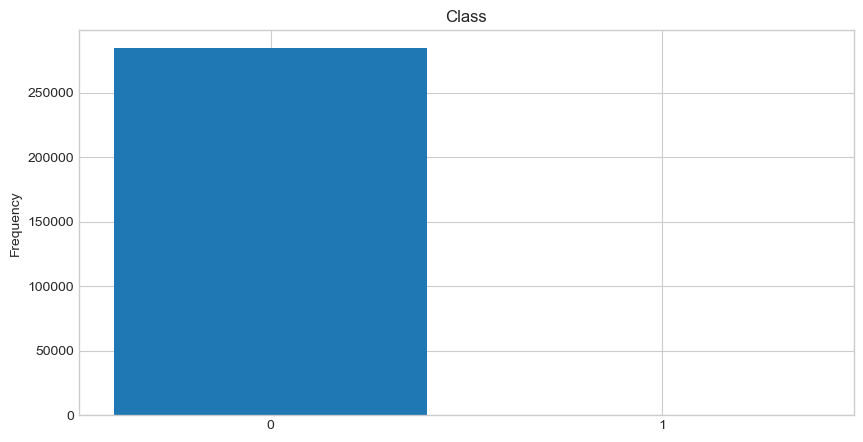

Class:Class
0    284315
1       492
Name: count, dtype: int64


In [51]:
category = ["Class"]
for c in category:
    bar_plot(c)

The class distribution plot shows that the dataset is highly imbalanced, with fraudulent transactions representing only 0.17% of the total data. This observation is crucial and will be considered during the modeling phase.

<font color = 'green'>
<a id ="5"></a>
    
### Numerical Variable

In this section, we analyze the numerical variables in the dataset to understand their distributions, central tendencies, and potential outliers.

First we create a array for numerical variables.

In [52]:
numerical_cols = train_df.select_dtypes(include="float").columns

To perform a more detailed analysis of the numerical variables, the describe() function is applied again to obtain comprehensive statistical summaries.

In [53]:
train_df[numerical_cols].describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000


  A histogram is plotted for each numerical variable to analyze its frequency distribution and identify possible anomalies in the data.

In [54]:
def plot_hist(variable):
    plt.figure(figsize=(8,5))
    plt.hist(train_df[variable], bins=50)
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title(f"distribution with hist {variable}")
    plt.show()

Since the dataset includes a large number of numerical features (V1–V28), only a subset of representative variables (Time, Amount, V1–V4) is visualized to demonstrate general distribution patterns.

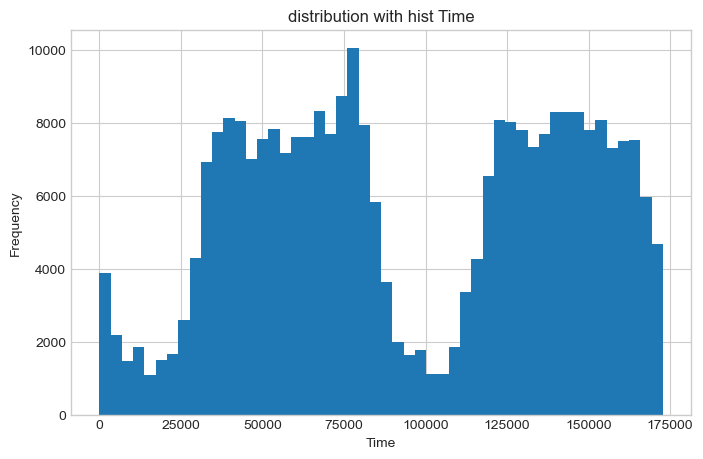

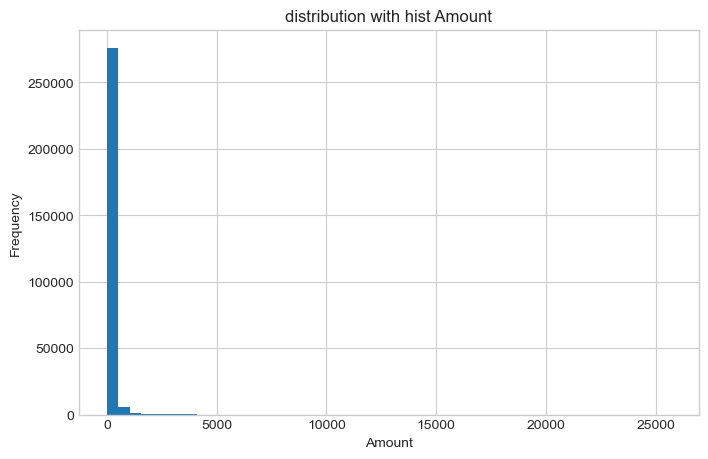

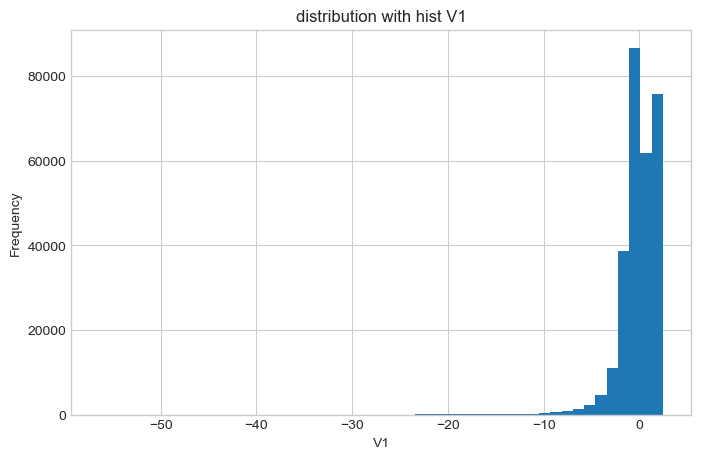

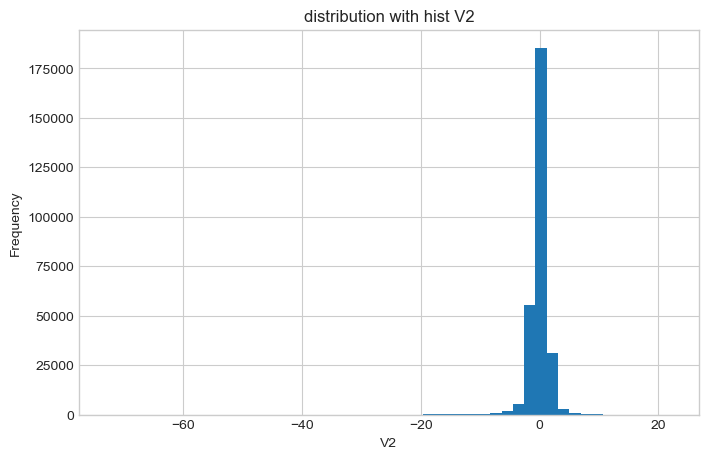

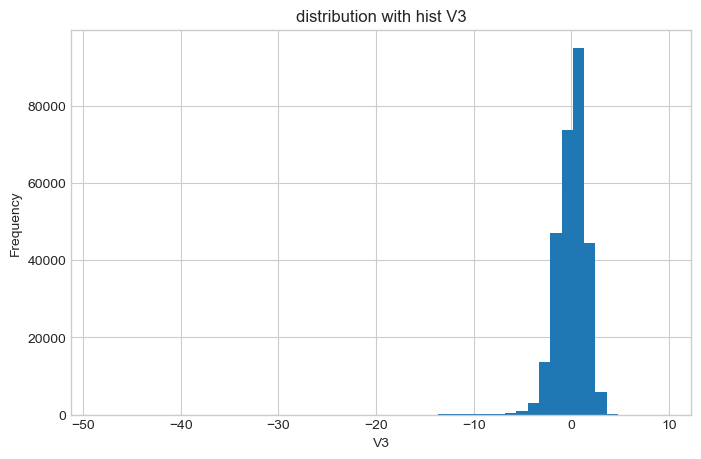

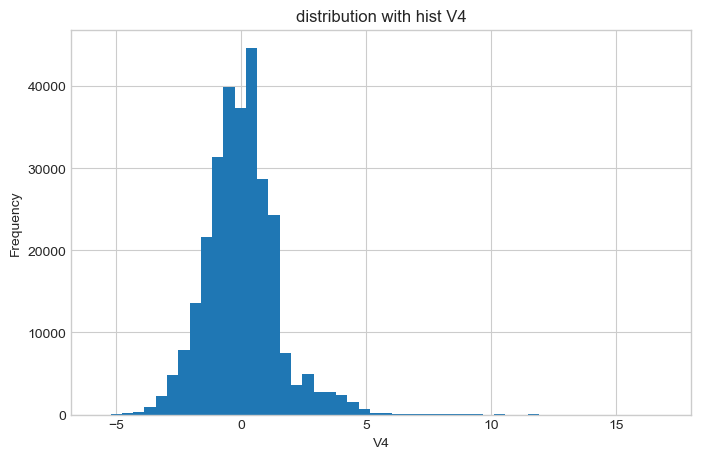

In [55]:
demo_cols = ["Time", "Amount","V1","V2","V3","V4"]
for c in demo_cols:
    plot_hist(c)

Most of the numerical features (V1–V28) are concentrated within a narrow range, reflecting the normalization effect of PCA transformation. The Amount variable shows a skewed distribution with most transactions are concentrated at low amounts, while a small number of transactions exhibit very large amounts. However, the Time feature demonstrates a relatively uniform distribution, suggesting that transactions are evenly distributed over the recorded time period.

<font color = 'red'>
<a id ="6"></a>


## Basic Data Analysis

In this section, we perform a basic data analysis by comparing numerical features across different classes in order to identify potential patterns related to fraudulent and legitimate transactions.


* Amount-Class
* Time-Class
* V2


There is a basic scatter plot code:

In [56]:
def plot_bivariate(x, y, df=train_df):
    plt.figure(figsize=(8,4))
    plt.scatter(df[x], df[y])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} vs {x}")
    plt.show()

<font color = 'brown'>


*  **Amount -  Class**

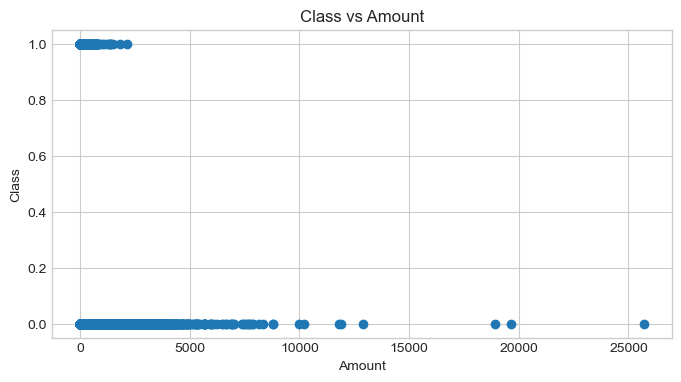

In [57]:
plot_bivariate("Amount", "Class")

The scatter plot between Amount and Class does not provide a clear visual separation due to the highly imbalanced nature of the dataset. Therefore, a boxplot representation is used to better compare the distribution of transaction amounts across the two classes.

Text(0.5, 1.0, 'Amount Distribution by Class')

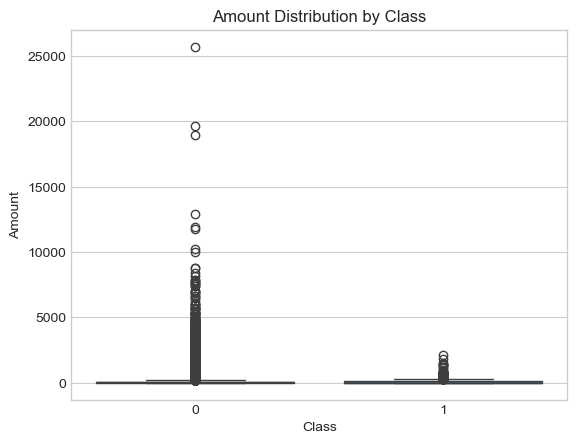

In [58]:
sns.boxplot(x="Class", y="Amount", data=train_df)
plt.title("Amount Distribution by Class")



In this part we calculate the mean of fraud and normal classes. We do this to check whether transaction amount differs between fraud and normal transactions and whether this variable can contribute to the classification task.

In [59]:
mean_amount = train_df.groupby("Class")["Amount"].mean().reset_index()
mean_amount


,Class,Amount
0,0,88.291022
1,1,122.211321


The mean transaction amount of fraudulent transactions is lower than that of legitimate transactions, indicating that fraud cases are mostly concentrated in smaller transaction amounts.

<font color = 'brown'>


*  **Time -  Class**

Text(0.5, 1.0, 'Time Distribution by Class')

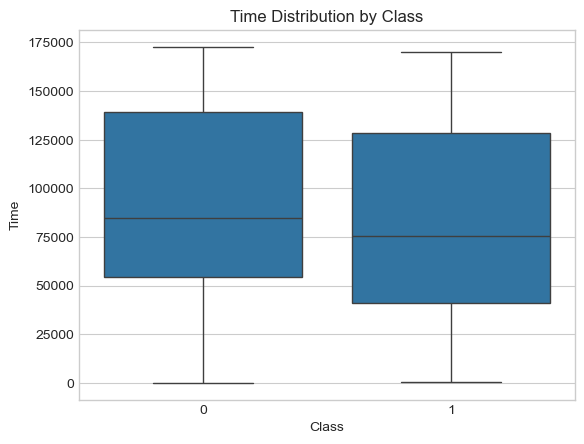

In [60]:
sns.boxplot(x="Class", y="Time", data=train_df)
plt.title("Time Distribution by Class")


The boxplot comparison of the Time variable across the two classes indicates that fraudulent and legitimate transactions have similar distributions. No clear separation pattern is observed between the classes, suggesting that the "Time" feature alone may not be a strong discriminative factor for fraud detection.

<font color = 'brown'>


*  **V1 -  Class**

Text(0.5, 1.0, 'V1 Distribution by Class')

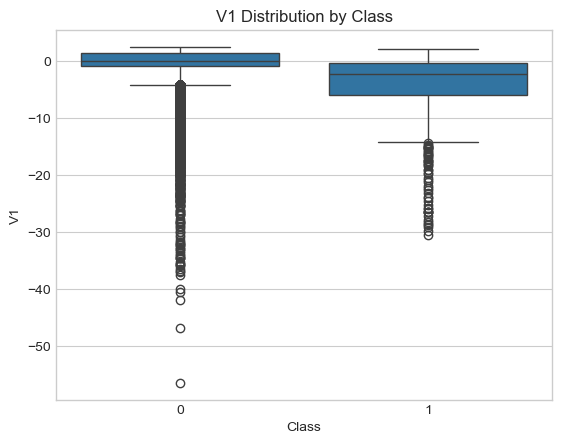

In [61]:
sns.boxplot(x="Class", y="V1", data=train_df)
plt.title("V1 Distribution by Class")


The boxplot comparison of the V1 variable across classes reveals a noticeable difference between fraudulent and legitimate transactions.This suggests that V1 may serve as an informative feature for distinguishing between fraud and normal cases.

<font color = 'red'>
<a id ="7"></a>


## Outlier Detection

Outlier detection is an important step in exploratory data analysis, as extreme values may indicate unusual transaction patterns that are potentially related to fraudulent behavior. In fraud detection problems, outliers often carry meaningful information rather than noise.

The code written for outlier detection using the IQR method is shown below.

In [62]:
def detect_outliers(df,col):
    outlier_indices = []
    for c in col:
        Q1 = np.percentile(df[c].dropna(), 25)
        Q3 = np.percentile(df[c].dropna(), 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_list_col = df[(df[c] < lower_bound) | (df[c] > upper_bound)].index
        outlier_indices.extend(outlier_list_col)
    outlier_indices = Counter(outlier_indices)
    multiple_outliers = list(i for i, v in outlier_indices.items() if v>1)
    return multiple_outliers

In [63]:
train_df.loc[detect_outliers(train_df,numerical_cols)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
18,14.0,-5.401258,-5.450148,1.186305,1.736239,3.049106,-1.763406,-1.559738,0.160842,1.233090,...,-0.503600,0.984460,2.458589,0.042119,-0.481631,-0.621272,0.392053,0.949594,46.80,0
85,55.0,-4.575093,-4.429184,3.402585,0.903915,3.002224,-0.491078,-2.705393,0.666451,1.922216,...,-0.047365,0.853360,-0.971600,-0.114862,0.408300,-0.304576,0.547785,-0.456297,200.01,0
140,87.0,-5.101877,1.897022,-3.458034,-1.277543,-5.517758,2.098366,3.329603,1.250966,0.271501,...,-0.871744,-0.678879,-0.555900,-0.761660,0.066611,0.767227,0.731634,-0.860310,919.60,0
146,92.0,-5.285971,4.847323,-1.290368,-1.427842,-0.621533,-0.604691,0.437866,0.336384,3.558373,...,-0.923604,-1.171187,0.150872,-0.493322,1.050554,0.194865,2.490503,1.575380,8.95,0
164,103.0,-6.093248,-12.114213,-5.694973,3.294389,-1.413792,4.776000,4.808426,-0.228197,-0.525896,...,2.228823,-2.264037,-3.553381,1.215279,-0.406073,-0.653384,-0.711222,0.672900,3828.04,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281714,170375.0,-0.668726,0.267670,-0.566598,-0.274168,0.334368,-1.028663,2.132333,-0.825006,0.094350,...,0.102476,1.038655,0.225278,0.005507,0.123622,-0.196650,-0.072343,-0.323807,212.58,0
281762,170405.0,-1.095761,0.719997,1.479664,-0.202178,-1.211261,0.073685,1.014417,0.085836,0.235637,...,0.222412,0.747974,-0.320606,0.047826,0.612377,-0.333956,-0.238301,-0.261372,202.50,0
282384,170862.0,-2.044064,-0.075241,-0.107687,-0.769675,-1.715016,0.665730,1.132021,0.761977,-0.214484,...,-0.051021,-0.477006,0.213959,0.755511,-0.532650,-0.413859,0.032805,-0.259686,431.15,0
284334,172350.0,-2.927939,-1.618923,-0.988158,-0.160083,1.118459,-0.611194,0.674021,0.355830,-0.073953,...,-0.097997,-0.665140,-0.497845,0.289087,0.028931,-0.138991,0.154306,-0.335637,301.44,0


Next, we examine the proportion of frauds among the dedected outliers.

In [64]:
outliers = detect_outliers(train_df, numerical_cols)
train_df.loc[outliers]["Class"].value_counts()


Class
0    80964
1      466
Name: count, dtype: int64

The results show that approximately 90% of fraudulent transactions are identified as outliers. This confirms that anomalous behavior is strongly associated with fraud cases, and removing outliers would lead to significant information loss. Therefore, outliers were not removed from the dataset.

<font color = 'red'>
<a id ="8"></a>

## Missing Values

In this step, we examine the dataset for missing values in order to ensure data quality before applying machine learning models.

In [65]:
train_df.isnull().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

No missing values were detected in the dataset. Therefore, no data imputation or cleaning was required for this step.

<font color = 'blue'>

# MACHINE LEARNING MODELING


<font  color = 'purple'>
Content:
   
1. [Problem Definition](#9)
2. [Data Preparation](#10)
3. [Evaluation Metrics](#11)
4. [Baseline Model: Logistic Regression](#12)
5. [Model Improvement: Hyperparameter Tuning](#13)
6. [Conclusion](#14)

<font color = 'red'>
<a id ="9"></a>

## Problem Definiton

The objective of this study is to develop a machine learning model capable of accurately detecting fraudulent credit card transactions. The task is formulated as a binary classification problem, where the target variable indicates whether a transaction is legitimate (Class = 0) or fraudulent (Class = 1).

A key challenge of this problem is the highly imbalanced nature of the dataset, as fraudulent transactions represent only a very small fraction of all observations. This imbalance requires careful model selection and appropriate evaluation metrics to ensure that fraud cases are effectively identified.

<font color = 'red'>
<a id ="10"></a>

## Data Preparation


In this section, we perform the necessary preprocessing steps to make the data suitable for classification models.

First, the input features and the target variable are separated for both training and testing sets.

In [66]:
df = pd.read_csv("creditcard.csv")

y = df["Class"]             
X = df.drop("Class", axis=1) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

print("İşlem tamam, test_df boyutu:", test_df.shape)

İşlem tamam, test_df boyutu: (56962, 31)


Then, feature scaling is applied to standardize the numerical variables so that all features have comparable ranges. This step is essential for models sensitive to feature magnitudes such as Logistic Regression.

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


<font color = 'red'>
<a id ="11"></a>

## Evaluation Metrics


Since the dataset is highly imbalanced, relying solely on Accuracy can be misleading. A model that predicts 'No Fraud' for every transaction would still have high accuracy but would fail to detect any fraud.

In [68]:

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(y_true, y_pred, y_prob):
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    print("\nROC-AUC Score:", roc_auc_score(y_true, y_prob))

We use the confusion matrix, recall, presicion and ROC-AUC Score to improve the accuracy of the program.

<font color = 'red'>
<a id ="12"></a>

## Baseline Model: Logistic Regression


First, we trained a standard Logistic Regression model. Due to the high class imbalance, the model biased towards the majority class, resulting in a near-zero Recall rate for fraud cases. However, the model was not successful in detecting fraudulent transactions.

Confusion Matrix:
[[56851    13]
 [   36    62]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score: 0.9605494455801453


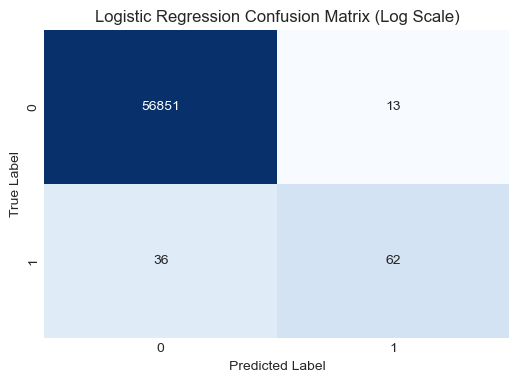

In [69]:
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import LogNorm

model = LogisticRegression( random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]
evaluate_model(y_test,y_pred,y_prob)


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', norm=LogNorm(), cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix (Log Scale)')
plt.show()


After training the model, we visualize the Confusion Matrix using a logarithmic scale to better observe the minority class (Fraud) performance against the overwhelming majority class.

<font color = 'red'>
<a id ="13"></a>

## Model Improvement

We are focusing on Logistic Regression that we learn about so far. So, in this section we will improve the model performance by tuning its hyperparameters instead of using complex 'Black Box' models.

<font color = 'green'>
<a id ="15"></a>
    
### Handling Class Imbalance

To address the limitations of the base model, we introduced the class_weight='balanced' parameter. This technique adjusts the weights inversely proportional to class frequencies in the input data. By assigning a higher penalty for misclassifying the minority class (fraud), the model is forced to prioritize detecting fraudulent transactions, significantly improving the Recall rate.


--- RESULTS FOR HANDLING CLASS IMBALANCE ---
Confusion Matrix:
[[55478  1386]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


ROC-AUC Score: 0.9720834996210077


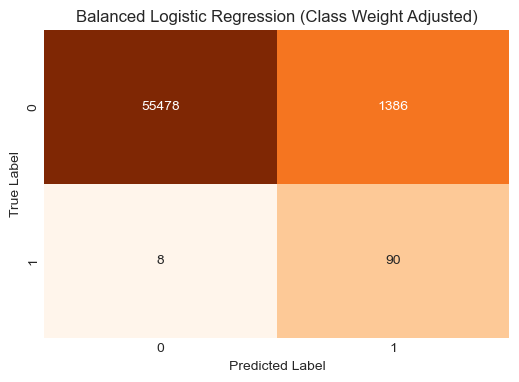

In [70]:
model_balanced = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)
y_prob_balanced = model_balanced.predict_proba(X_test_scaled)[:,1]

print("\n--- RESULTS FOR HANDLING CLASS IMBALANCE ---")
evaluate_model(y_test, y_pred_balanced, y_prob_balanced)

cm = confusion_matrix(y_test, y_pred_balanced)
plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', norm=LogNorm(), cbar=False)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Balanced Logistic Regression (Class Weight Adjusted)')
plt.show()

<font color = 'green'>
<a id ="15"></a>
    
### C Value

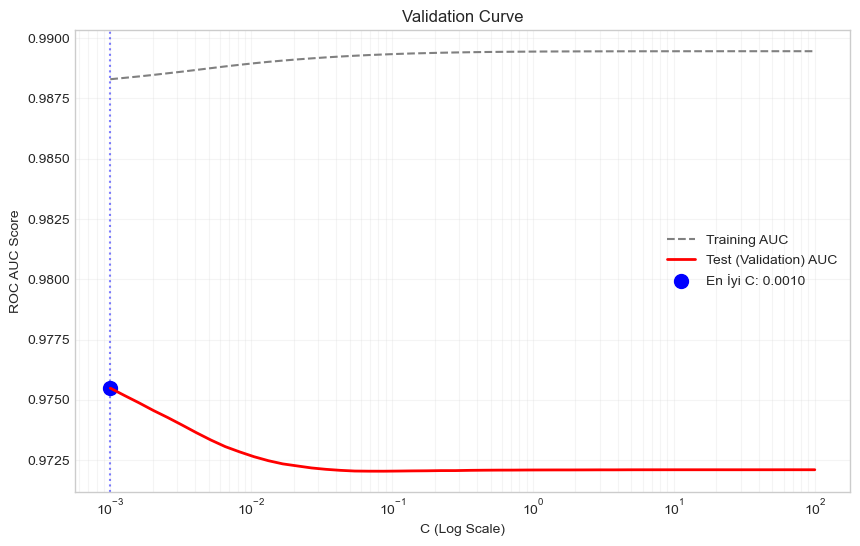

According to the graph, the peak point was reached at C = 0.00100.


In [71]:
c_values = np.logspace(-3, 2, 50) 

train_scores = []
test_scores = []


for c in c_values:
    
    model = LogisticRegression(C=c, solver='liblinear', class_weight='balanced', random_state=42, max_iter=1000)
    model.fit(X_train_scaled, y_train)
    
    
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train_scaled)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
    
    train_scores.append(train_auc)
    test_scores.append(test_auc)

plt.figure(figsize=(10, 6))
plt.plot(c_values, train_scores, label='Training AUC', linestyle='--', color='gray')
plt.plot(c_values, test_scores, label='Test (Validation) AUC', color='red', linewidth=2)

plt.xscale('log') 

best_idx = np.argmax(test_scores)
best_c = c_values[best_idx]
best_score = test_scores[best_idx]

plt.scatter(best_c, best_score, s=100, c='blue', label=f'En İyi C: {best_c:.4f}')
plt.axvline(x=best_c, color='blue', linestyle=':', alpha=0.5)

plt.title('Validation Curve')
plt.xlabel('C (Log Scale)')
plt.ylabel('ROC AUC Score')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()
print(f"According to the graph, the peak point was reached at C = {best_c:.5f}.")

To optimize the Logistic Regression model, We performed a hyperparameter tuning analysis on the inverse regularization strength parameter. Using a validation curve approach with 50 logarithmically spaced values, we evaluated the model's performance based on the ROC AUC metric. This analysis allowed us to visually identify the trade-off between bias and variance, selecting the optimal C value that maximizes generalization on the test set while preventing overfitting.

<font color = 'green'>
<a id ="16"></a>
    
### Threshold

The standard default threshold of 0.5 does not yield sufficiently good results for imbalanced datasets. However, setting the threshold too low significantly increases the False Positive Rate, causing unnecessary workload for the bank. Therefore, in the function written below, we aimed to reach the optimal result for this trade-off."

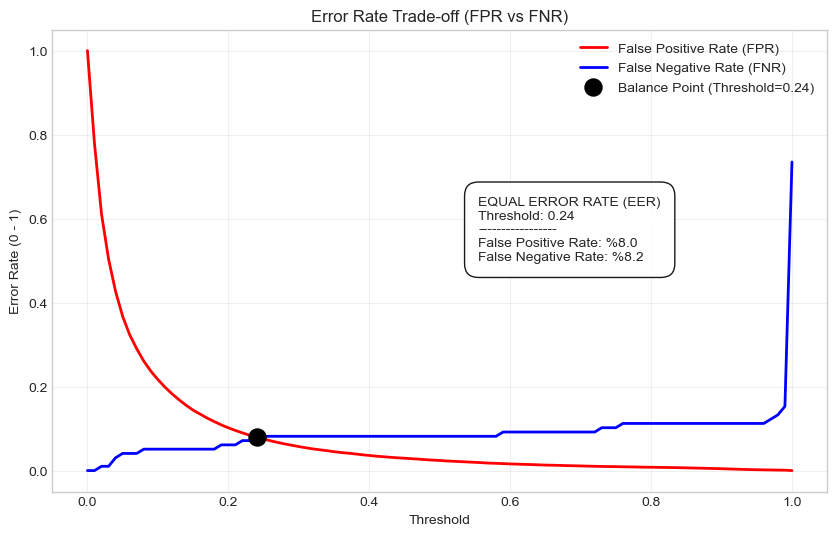

In [72]:
best_model = LogisticRegression(C=0.01, penalty='l2', solver='liblinear', class_weight='balanced', random_state=42)
best_model.fit(X_train_scaled, y_train)

y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

thresholds = np.linspace(0, 1, 101)

fpr_list = [] 
fnr_list = [] 

for t in thresholds:
    y_pred_temp = (y_pred_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()
    
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    fpr_list.append(fpr)
    fnr_list.append(fnr)

plt.figure(figsize=(10, 6))


plt.plot(thresholds, fpr_list, label='False Positive Rate (FPR)', color='red', linewidth=2)
plt.plot(thresholds, fnr_list, label='False Negative Rate (FNR)', color='blue', linewidth=2)

idx = np.argmin(np.abs(np.array(fpr_list) - np.array(fnr_list)))
eer_threshold = thresholds[idx]
eer_rate = fpr_list[idx] 

plt.scatter(eer_threshold, eer_rate, s=150, c='black', zorder=5, label=f'Balance Point (Threshold={eer_threshold:.2f})')


plt.title('Error Rate Trade-off (FPR vs FNR)')
plt.xlabel('Threshold')
plt.ylabel('Error Rate (0 - 1)')
plt.grid(True, alpha=0.3)
plt.legend()


info_text = (
    f"EQUAL ERROR RATE (EER)\n"
    f"Threshold: {eer_threshold:.2f}\n"
    f"-----------------\n"
    f"False Positive Rate: %{fpr_list[idx]*100:.1f}\n"
    f"False Negative Rate: %{fnr_list[idx]*100:.1f}"
)
plt.text(0.55, 0.5, info_text, transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=1'))

plt.show()

As a result of this function, we identified 0.24 as the optimal threshold. We then applied this value, along with the optimized C parameter, to the final model.

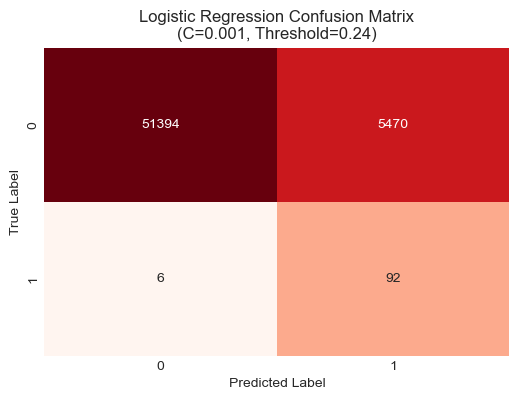

In [73]:
model_final = LogisticRegression(C=0.001, solver='liblinear', class_weight='balanced', random_state=42)
model_final.fit(X_train_scaled, y_train)

y_prob = model_final.predict_proba(X_test_scaled)[:, 1]

custom_threshold = 0.24
y_pred = (y_prob >= custom_threshold).astype(int)


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', norm=LogNorm(), cbar=False)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Logistic Regression Confusion Matrix\n(C=0.001, Threshold={custom_threshold})')
plt.show()

<font color = 'red'>
<a id ="14"></a>

## Conclusion

In this project, we developed a Logistic Regression model to detect credit card fraud. Since the dataset was highly imbalanced, relying on standard accuracy was insufficient.So, we focused on improving Recall to minimize missed fraud cases.

This approach consisted of two key steps to handle the imbalance and improve performance:
1. We used the class_weight='balanced' parameter to assign a higher importance to the minority class. This ensured that the model focused more on fraud cases during training.

2. The standard decision threshold was too conservative for this domain. Consequently, we lowered the threshold. Although this leads to more false alarms (False Positives), detecting fraud is prioritized over avoiding false alarms.

In conclusion, the final model is much more sensitive and effective at catching potential fraud than the baseline model.


--- PERFORMANCE COMPARISON ---
                           Base Model (Default)  Tuned Model (Final)
Recall (Fraud Catch Rate)              0.632653             0.938776
Precision                              0.826667             0.016541
F1 Score                               0.716763             0.032509
ROC AUC                                0.960549             0.975486
Accuracy                               0.999140             0.903866


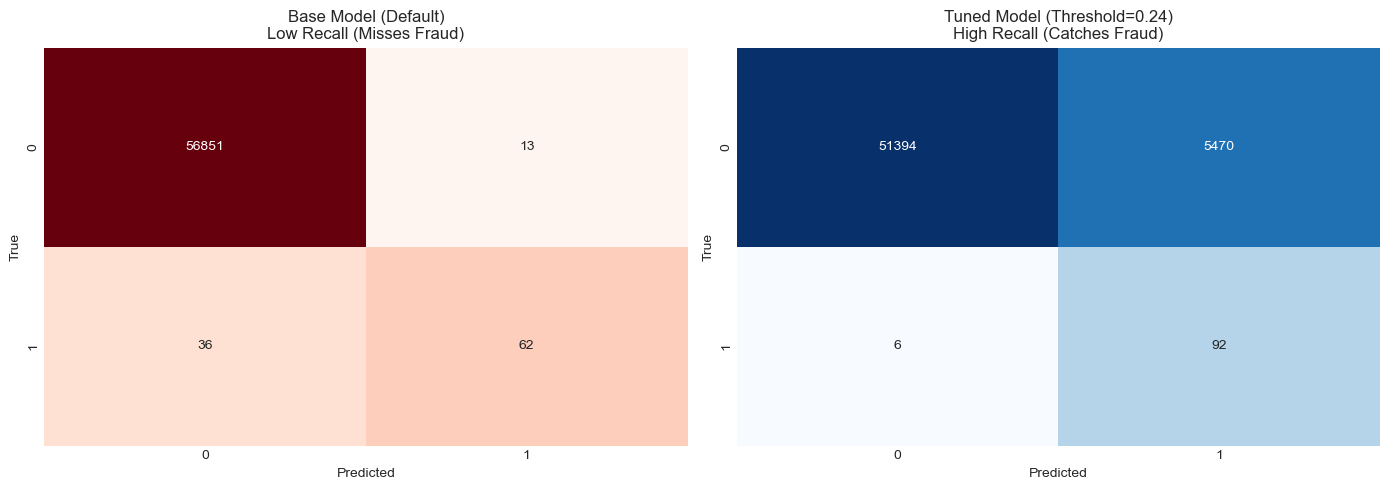

In [74]:
## Base Model

base_model = LogisticRegression(random_state=42)
base_model.fit(X_train_scaled, y_train)

y_pred_base = base_model.predict(X_test_scaled)
y_prob_base = base_model.predict_proba(X_test_scaled)[:, 1]

# Final Model
final_threshold = 0.24
y_prob_tuned = model_final.predict_proba(X_test_scaled)[:, 1]
y_pred_tuned = (y_prob_tuned >= final_threshold).astype(int)


def get_metrics(y_true, y_pred, y_prob):
    return {
        'Recall (Fraud Catch Rate)': recall_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, y_prob),
        'Accuracy': accuracy_score(y_true, y_pred)
    }

base_metrics = get_metrics(y_test, y_pred_base, y_prob_base)
tuned_metrics = get_metrics(y_test, y_pred_tuned, y_prob_tuned)

comparison_df = pd.DataFrame([base_metrics, tuned_metrics], index=['Base Model (Default)', 'Tuned Model (Final)'])
comparison_df = comparison_df.T 

print("\n--- PERFORMANCE COMPARISON ---")
print(comparison_df)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Base Model Grafiği
sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt='d', cmap='Reds', ax=axes[0], norm=LogNorm(), cbar=False)
axes[0].set_title('Base Model (Default)\nLow Recall (Misses Fraud)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Tuned Model Grafiği
sns.heatmap(confusion_matrix(y_test, y_pred_tuned), annot=True, fmt='d', cmap='Blues', ax=axes[1], norm=LogNorm(), cbar=False)
axes[1].set_title(f'Tuned Model (Threshold={final_threshold})\nHigh Recall (Catches Fraud)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()